# Confronto tra modelli, hold-out e cross-validation 

*Docenti*: Luca Calatroni, Lorenzo Rosasco


Definiamo una pipeline per confrontare due modelli di classificazione binaria:
1. `RidgeClassifier`: modello lineare collegato alla loss quadratica;
2. `DecisionTreeClassifier`: modello non lineare basato su split successivi.

Il dataset è già numerico e pulito. Il focus è su:
- train / validation / test split;
- hold-out per la selezione del modello;
- test finale;
- matrice di confusione;
- cross-validation.


In [1]:
# Import delle librerie necessarie

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


## 1. Caricamento del dataset

Utilizziamo il dataset Breast Cancer che fornisce un problema di classificazione binaria:
- input: feature numeriche;
- output: classe del tumore

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Classi:", data.target_names)
print("Target:", np.unique(y))

print("\nDistribuzione classi:")
for label, name in enumerate(data.target_names):
    print(name, ":", np.sum(y == label))


Shape X: (569, 30)
Shape y: (569,)
Classi: ['malignant' 'benign']
Target: [0 1]

Distribuzione classi:
malignant : 212
benign : 357


- Le classi sono bilanciate?

## 2. Modelli da confrontare

### Modello lineare con loss quadratica

La funzione che lo invoca è `RidgeClassifier`. È un modello lineare:

$$
f(x) = w^\top x + b
$$

collegato alla minimizzazione di una loss quadratica a cui, come nel caso logistico, viene aggiunta una regolarizzazione quadratica:

$$
\sum_i (y_i - f(x_i))^2 + \alpha \|w\|^2
$$

La regola di classificazione viene poi definita tramite regola:

$$
\hat{y}(x) = \begin{cases}
1\quad&\quad f(x)\geq 0.5 \\
0\quad&\quad \text{altrimenti}
\end{cases}
$$

### Albero decisionale

Un albero decisionale costruisce regole del tipo:

$$
x_j \leq t
$$

Il parametro `max_depth` controlla la complessità dell'albero.


Utilizziamo lo scaling delle features per il modello di ridge regression.

Per l'albero lo scaling non è necessario, perché gli split dipendono da soglie sulle singole feature.


In [3]:
# TO DO: definire le pipeline

# Fissare un valore dell'iperaparametro alpha a piacere
# Fissare un valore di profondità dell'albero a piacere

alpha_value=0.1
max_depth_value=5

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",RidgeClassifier(alpha=alpha_value))
])

tree_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(max_depth=max_depth_value, random_state=42))
])


## 3. Train, validation e test

Se abbiamo un solo modello, possiamo addestrarlo sul training set e valutarlo sul test set.

Se invece vogliamo scegliere tra più modelli, non dobbiamo usare il test set per scegliere il modello migliore.  
Il test set deve essere usato solo alla fine, una volta scelto il modello migliore tra quelli testati. Se lo usiamo per scegliere il modello, smette di essere indipendente e non misura più correttamente la qualità del modello.

Usiamo quindi:

1. **training set**: addestra i modelli;
2. **validation set / hold-out set**: sceglie il modello;
3. **test set**: valuta una sola volta il modello scelto.

In [4]:
# Primo split: separiamo il test set finale creando variabili X_temp e y_temp che verranno poi divise ulteriormente

X_temp,X_test,y_temp,y_test = train_test_split(X,y,test_size=0.2,random_state=42,
    stratify=y  # --> il comando stratify sceglie lo split mantenendo le proporzioni tra le classi presenti in y
)

# Secondo split: da X_temp ricaviamo train e validation

X_train,X_val,y_train,y_val = train_test_split(X_temp,y_temp,test_size=0.25,random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (341, 30)
Validation: (114, 30)
Test: (114, 30)


## 4. Hold-out method

Il validation set gioca il ruolo di hold-out set, ovvero l'insieme su cui testiamo la qualità del modello trainato sul training set. Se abbiamo modelli $f_1, \dots, f_M$, scegliamo quello con errore di validation più basso, o accuracy più alta, dove la misura di accuracy qui è data da:

$$
\text{accuracy}(y^{val},\hat{y}^{val}) = \frac{1}{n}\sum_i \mathbb{1}_{ \left\{y^{val}_i = \hat{y}^{val}_i\right\}}
$$

In [5]:
# Modello lineare
# TO DO: effettuare il fit e valutare l'accuracy
linear_pipeline.fit(X_train,y_train)
y_val_pred_linear = linear_pipeline.predict(X_val)
val_acc_linear = accuracy_score(y_val, y_val_pred_linear)

# Albero decisionale
# TO DO: effettuare il fit e valutare l'accuracy
tree_pipeline.fit(X_train, y_train)
y_val_pred_tree = tree_pipeline.predict(X_val)
val_acc_tree = accuracy_score(y_val, y_val_pred_tree)

print("Validation accuracy - Lineare:", val_acc_linear)
print("Validation accuracy - Tree:", val_acc_tree)


Validation accuracy - Lineare: 0.9122807017543859
Validation accuracy - Tree: 0.956140350877193


In [6]:
# TO DO: Scegliere il modello migliore

if val_acc_linear > val_acc_tree:
    best_model_name = "Ridge regression"
    final_model = linear_pipeline
else:
    best_model_name = "Decision Tree"
    final_model = tree_pipeline

print(best_model_name)

Decision Tree


## 5. Matrice di confusione

La matrice di confusione fornisce una rappresentazione visuale degli errori compiuti in vase di validazione, confrontando etichette vere e predette. Tramite opportune operazioni, fornisce anche un modo alternativo per il calcolo dell'accuratezza.

Per classificazione binaria la matrice di confusione è definita come:

$$
\begin{array}{c|cc}
 & \hat{y}=1 & \hat{y}=0 \\
\hline
y=1 & TP & FN \\
y=0 & FP & TN
\end{array}
$$

dove:
- **TP**: numero veri positivi (quanti elementi di classe 1 vengono predetti avere classe 1);
- **TN**: numero veri negativi (quanti elementi di classe 0 vengono predetti avere classe 0);
- **FP**: falsi positivi (quanti elementi di classe 0 vengono predetti avere classe 1);
- **FN**: falsi negativi (quanti elementi di classe 1 vengono predetti avere classe 0).

Da questa matrice è possibile definire l'accuratezza come:

$$
\mathrm{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

La matrice di confusione è utile perché due modelli possono avere accuracy simile ma fare errori diversi (sbagliare sui positive, o sui negative).


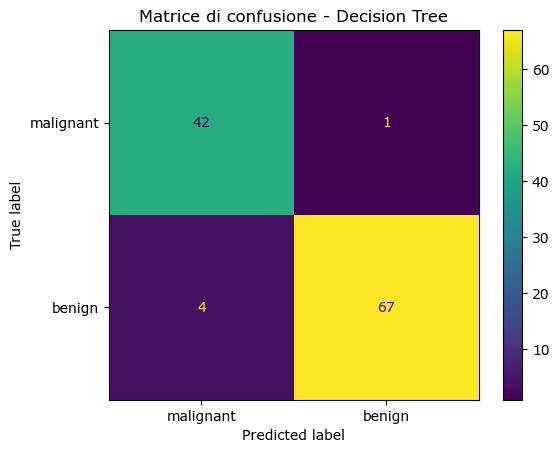

Accuracy (da matrice) - Decision Tree: 0.9561


In [7]:
cm = confusion_matrix(y_val, y_val_pred_tree)

# TO DO: calcolare l'accuratezza utilizzando operazioni sulla matrice di confusione
acc_from_cm = np.trace(cm) / np.sum(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title(f"Matrice di confusione - {best_model_name}")
plt.show()

print(f"Accuracy (da matrice) - {best_model_name}: {acc_from_cm:.4f}")


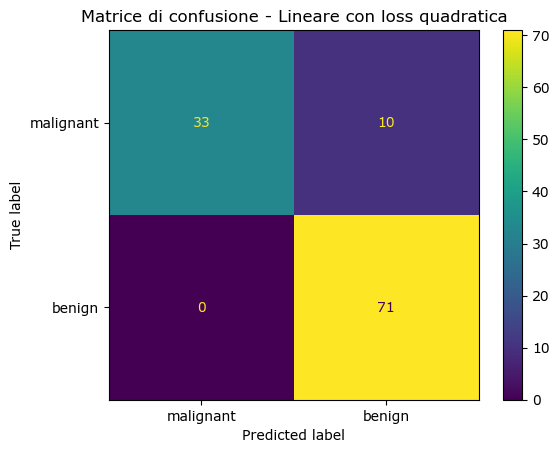

Accuracy (da matrice) - Lineare con loss quadratica: 0.9123


In [8]:
# Matrice di confusione del modello lineare

# TO DO: effettuare le stesse operazioni di cui sopra

cm_linear =  confusion_matrix(y_val, y_val_pred_linear)
acc_linear_from_cm = np.trace(cm_linear) / np.sum(cm_linear)

disp_linear = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear,
    display_labels=data.target_names
)

disp_linear.plot()
plt.title("Matrice di confusione - Lineare con loss quadratica")
plt.show()

print(f"Accuracy (da matrice) - Lineare con loss quadratica: {acc_linear_from_cm:.4f}")


Dopo aver scelto il modello migliore usando il validation set, possiamo riaddestrarlo considerando come training set l'unione:

$$
\text{train} \cup \text{validation}
$$

e valutarlo una sola volta sul test set (come abbiamo fatto solitamente).


In [9]:
# Effettuiamo il fit sull'unione dei train e validation set e testiamo sul test set

# TO DO: effettuare il fit, le predizioni e il calcolo dell'accuracy

final_model.fit(X_temp, y_temp)
y_test_pred = final_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)

print("Test accuracy:", test_acc)


Test accuracy: 0.9210526315789473


## 6. Variabilità del metodo hold-out

Il metodo hold-out dipende dallo split.  
Cambiare `random_state` può cambiare gli score e anche il modello migliore selezionato. Testiamo diversi seed per vedere la variabilità.

In [10]:
seeds = range(15)

linear_val_scores = []
tree_val_scores = []
chosen_models = []

for seed in seeds:

    # TO DO: incorpora la varaibilità dello split

    X_temp_s, X_test_s, y_temp_s, y_test_s = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
        X_temp_s, y_temp_s, test_size=0.25, random_state=seed, stratify=y_temp_s
    )

    linear_pipeline.fit(X_train_s,y_train_s)
    tree_pipeline.fit(X_train_s,y_train_s)

    y_val_pred_linear_s = linear_pipeline.predict(X_val_s)
    y_val_pred_tree_s = tree_pipeline.predict(X_val_s)

    linear_score = accuracy_score(y_val_s,y_val_pred_linear_s)
    tree_score = accuracy_score(y_val,y_val_pred_tree_s)
    
    linear_val_scores.append(linear_score)
    tree_val_scores.append(tree_score)

    # TO DO: scegliere il modello migliore sulla base del valore dell'accuracy calcolata sullo split considerato

    chosen_models.append("Ridge" if linear_score>tree_score  else "Tree")

print("Score validation Ridge:")
print(np.round(linear_val_scores, 3))

print("\nScore validation Tree:")
print(np.round(tree_val_scores, 3))

print("\nModelli scelti:")
print(chosen_models)


Score validation Ridge:
[0.956 0.956 0.974 0.956 0.974 0.947 0.982 0.93  0.947 0.947 0.956 0.921
 0.939 0.965 0.956]

Score validation Tree:
[0.474 0.474 0.456 0.544 0.623 0.605 0.579 0.526 0.439 0.596 0.5   0.509
 0.465 0.588 0.535]

Modelli scelti:
['Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge', 'Ridge']


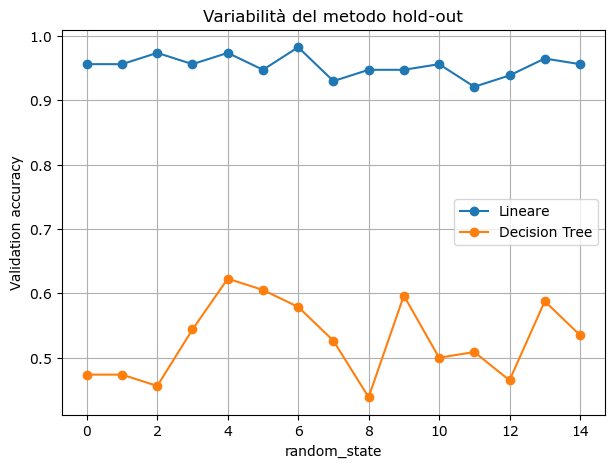

In [11]:
plt.figure(figsize=(7, 5))
# TO DO: visualizza la variabilità nel calcolo dell'accuracy
plt.plot(seeds,linear_val_scores, marker="o", label="Lineare")
plt.plot(seeds,tree_val_scores, marker="o", label="Decision Tree")
plt.xlabel("random_state")
plt.ylabel("Validation accuracy")
plt.title("Variabilità del metodo hold-out")
plt.legend()
plt.grid(True)
plt.show()


## 7. Cross-validation

La cross-validation ripete l'idea di considerare un set ausiliario (validation) lasciandolo variare e considerando dunque più split definiti in modo aleatorio.

Nel k-fold CV:

1. si divide il dataset in $k$ blocchi;
2. si allena su $k-1$ blocchi;
3. si valida sul blocco rimasto fuori;
4. si ripete il processo $k$ volte considerando, a rotazione, blocchi diversi per test e validation;
5. si definiscono gli accuracy scores:

$$
s_1, \dots, s_k
$$

E si calcolano le statistiche empiriche:

$$
\hat{s} = \frac{1}{k}\sum_{r=1}^k s_r
\quad\text{(media)}
$$

$$
\sigma_{\hat{s}} = \sqrt{\frac{1}{k}\sum_{r=1}^k (s_r - \hat{s})^2}
\quad\text{(deviazione standard, stima biased)}
$$

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # shuffle=True rimescola i dati per evitare bias di ordinamento


# Definiamo la pipeline di cross validation: l'output sono i valori dello score selezionato (in questo caso accuracy)

linear_cv_scores = cross_val_score(
    linear_pipeline, X, y, cv=cv, scoring="accuracy"
)

tree_cv_scores = cross_val_score(
    tree_pipeline, X, y, cv=cv, scoring="accuracy"
)

# TO DO: mostrare i valori e calcolarne media e SD

print("CV Rdige:", np.round(linear_cv_scores,3))
print("Media:", np.round(linear_cv_scores.mean(),3))
print("Std:", np.round(linear_cv_scores.std(),3))

print("\nCV Tree:", np.round(tree_cv_scores,3))
print("Media:", np.round(tree_cv_scores.mean(),3))
print("Std:", np.round(linear_cv_scores.std(),3))


CV Rdige: [0.965 0.947 0.921 0.974 0.973]
Media: 0.956
Std: 0.02

CV Tree: [0.939 0.886 0.93  0.93  0.956]
Media: 0.928
Std: 0.02


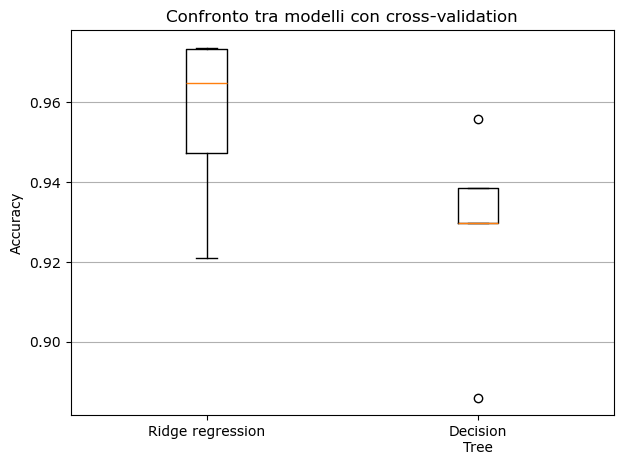

In [13]:
# Visualizziamo con un box plot i grafici di accuratezza

scores = [linear_cv_scores, tree_cv_scores]
labels = ["Ridge regression", "Decision\nTree"]

plt.figure(figsize=(7, 5))
plt.boxplot(scores, tick_labels=labels)
plt.ylabel("Accuracy")
plt.title("Confronto tra modelli con cross-validation")
plt.grid(axis="y")
plt.show()


## 8. Ispezione dei modelli

Visualizziamo i pesi trovati dal modello di ridge regression e cerchiamo di capire quali sono quelli più utili alla predizione

In [21]:
# TO DO trainare sull'insieme di train + validation

linear_pipeline.fit(X_temp, y_temp)
linear_model = linear_pipeline.named_steps["model"]

feature_names = data.feature_names
coefficients = linear_model.coef_

print("Shape coefficienti:", linear_model.coef_.shape)
print("Intercept:", linear_model.intercept_)
print("Componenti di w:")
print(coefficients[:])


Shape coefficienti: (30,)
Intercept: [0.25274725]
Componenti di w:
[ 0.37718423 -0.06368949 -0.41163713  0.0564008  -0.03515647  0.48889717
 -0.24199974 -0.07952151 -0.0248507  -0.06329753 -0.33127079 -0.01336498
  0.18768053  0.03731779 -0.11122932 -0.03354234  0.28345756 -0.1579923
  0.015956    0.05315333 -1.31029463 -0.07246123 -0.03456563  0.92550886
 -0.00190436 -0.02702724 -0.21729469 -0.12044602 -0.09187422 -0.12153298]


### Coefficienti piccoli e correlazioni tra feature

Per il modello lineare, coefficienti con valore assoluto vicino a 0 suggeriscono che la feature contribuisce poco alla decisione. Tuttavia, la presenza di feature correlate puo' rendere l'interpretazione dei pesi meno immediata: informazione simile puo' essere distribuita tra piu' variabili.

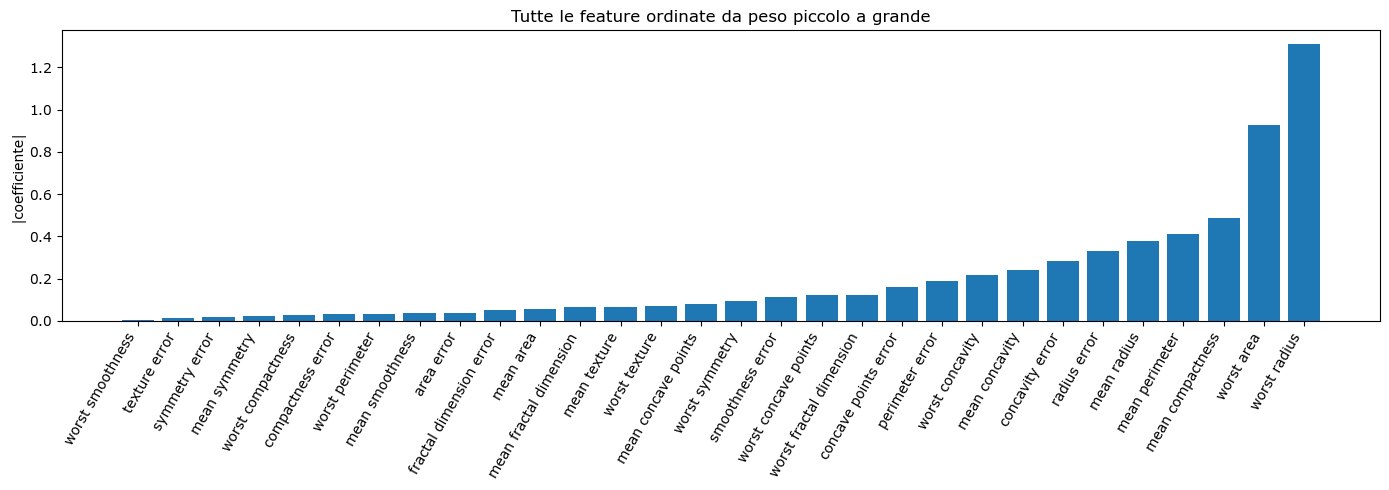

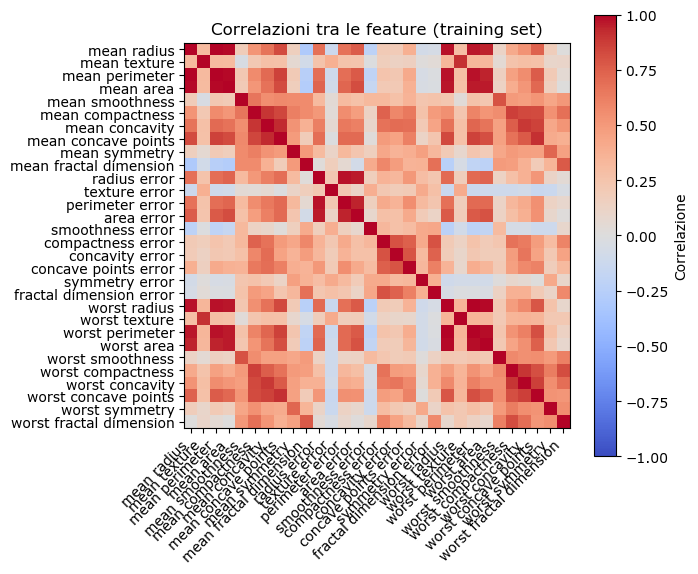

In [22]:
# TO DO: ordiniamo i coefficienti in ordine crescente calcolando il modulo

abs_coefficients =np.abs(coefficients)
sorted_idx = np.argsort(abs_coefficients)

plt.figure(figsize=(14, 5))
plt.bar(feature_names[sorted_idx], abs_coefficients[sorted_idx], color="tab:blue")
plt.ylabel("|coefficiente|")
plt.title("Tutte le feature ordinate da peso piccolo a grande")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


# TO DO: calcolare la matrice di correlazione tra le feature nell'insieme di training

corr_top = np.corrcoef(X_temp, rowvar=False)

plt.figure(figsize=(7, 6))
image = plt.imshow(corr_top, cmap="coolwarm", vmin=-1, vmax=1)
range = np.arange(len(feature_names))
plt.colorbar(image, label="Correlazione")
plt.xticks(range, feature_names, rotation=45, ha="right")
plt.yticks(range, feature_names)
plt.title("Correlazioni tra le feature (training set)")
plt.tight_layout()
plt.show()